<a href="https://colab.research.google.com/github/Rashedulislam00/Binary-Classification-of-Bike-vs.-Car-using-Deep-Learning/blob/main/Car_vs_Bike_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Bike vs car dataset is in googledrive, so from colab I am accessing my drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files

#In order to import the datsets from kaggle the API token has been uploaded
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"my-username","key":"the_key"}'}

In [ ]:
#In collab a kaggle folder is created
!mkdir -p ~/.kaggle
#Followed by copying the kaggel.json token into the folder
!cp kaggle.json ~/.kaggle/
#Providing a suitable permission for the token
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# From kaggle the dataset is downloaded
!kaggle datasets download -d utkarshsaxenadn/car-vs-bike-classification-dataset
# Unzip the car vs bike dataset
!unzip -q car-vs-bike-classification-dataset.zip -d dataset/


Dataset URL: https://www.kaggle.com/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset
License(s): CC0-1.0
100% 103M/103M [00:01<00:00, 76.1MB/s]



In [ ]:
import os
import shutil
import random

# Folder destination
original_dataset_dir = "/content/dataset/Car-Bike-Dataset"

# New folder for the split train/test dataset
base_dir = "/content/car_bike_split"

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

# Creating main folder for train/test
for folder in [train_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)


# Class definition
classes = ["Car", "Bike"]


# Creating class folders within main folders
for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

# ratio split
split_ratio = 0.8


# Splitting the dataset
for cls in classes:

    source_folder = os.path.join(original_dataset_dir, cls)

    images = os.listdir(source_folder)

    # Shuffling of images at random
    random.shuffle(images)

# 80% split
    split_index = int(len(images) * split_ratio)

# images are split into training and testing sets
    train_images = images[:split_index]
    test_images = images[split_index:]

    # Training copy
    for img in train_images:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(train_dir, cls, img)
        )

    # Testing copy
    for img in test_images:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(test_dir, cls, img)
        )

In [ ]:
train_dir = "/content/car_bike_split/train"
test_dir = "/content/car_bike_split/test"

In [ ]:
import os

print("Train Car:",
      len(os.listdir(os.path.join(train_dir, "Car"))))

print("Train Bike:",
      len(os.listdir(os.path.join(train_dir, "Bike"))))

print("Test Car:",
      len(os.listdir(os.path.join(test_dir, "Car"))))

print("Test Bike:",
      len(os.listdir(os.path.join(test_dir, "Bike"))))

Train Car: 1600
Train Bike: 1600
Test Car: 400
Test Bike: 400


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Original dataset path
dataset_dir = "/content/Car-Bike-Dataset"

# ImageDataGenerator creation for the training data set
train_datagen = ImageDataGenerator(
    rescale=1./255, #normalisation
    validation_split=0.2  # Split 20% of the images for validation
)

# Training data loading and preparing
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',  # 'binary' for binary classification (bike vs car)
    subset='training'  # For the training set specify 'training'
)
# ImageDataGenerator creation for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Note: Using the same validation split as in the training set
)

# Validation data loading and preparation
validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary', # 'binary' for binary classification (bike vs car)
    subset='validation'  # For the validation set specify 'validation'
)

Found 2560 images belonging to 2 classes.
Found 640 images belonging to 2 classes.


In [ ]:
#Importing necessary libaraies for CNN deep learning model
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,UpSampling2D, Dropout

In [ ]:
# Creating custom CNN model

model = Sequential()

model.add(Conv2D(32, (3,3), padding='valid', activation='relu', input_shape=(256,256,3))) #32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64, (3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128, (3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu')) #Feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid')) #Output layer to conduct the binary classification

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
#binary_crossentropy - binary classification

In [ ]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)
#fewer epochs are used since the dataset is small

Epoch 1/10
31/80 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.5074 - loss: 0.8798

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 145ms/step - accuracy: 0.7082 - loss: 0.5522 - val_accuracy: 0.8813 - val_loss: 0.3111
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.9117 - loss: 0.2139 - val_accuracy: 0.8703 - val_loss: 0.3063
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.9520 - loss: 0.1250 - val_accuracy: 0.9094 - val_loss: 0.2544
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - accuracy: 0.9812 - loss: 0.0484 - val_accuracy: 0.8844 - val_loss: 0.3976
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.9879 - loss: 0.0360 - val_accuracy: 0.9094 - val_loss: 0.3155
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.9965 - loss: 0.0201 - val_accuracy: 0.9109 - val_loss: 0.4007
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9047 - val_loss: 0.5323
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - accuracy: 1.0000 - loss: 6.6884e-04 - val_accuracy: 0

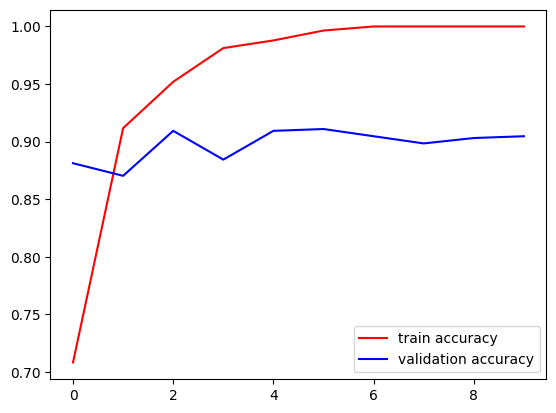

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train accuracy')
plt.plot(history.history['val_accuracy'],color='blue',label='validation accuracy')
plt.legend()
plt.show()

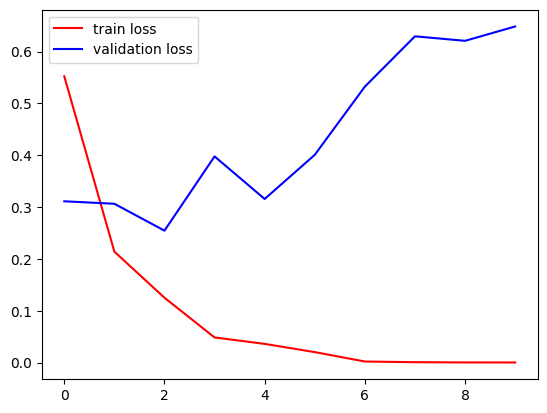

In [ ]:
plt.plot(history.history['loss'],color='red',label='train loss')
plt.plot(history.history['val_loss'],color='blue',label='validation loss')
plt.legend()
plt.show()

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 800 images belonging to 2 classes.


In [ ]:
predictions = model.predict(test_data)

 7/25 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming the availabilty truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)

# Confusion matrix calculation
cm = confusion_matrix(true_labels, predicted_labels)

# Confusion matrix printing
print("Confusion Matrix:")
print(cm)

# Print the classification report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[345  55]
 [ 29 371]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       400
           1       0.87      0.93      0.90       400

    accuracy                           0.90       800
   macro avg       0.90      0.90      0.89       800
weighted avg       0.90      0.90      0.89       800



There is overfitting beacuse it performed well on training data but predicts wrong in testing data and hence applying Batchnormalisation and Dropout techniques to handle overfitting

In [ ]:
# CNN model creation

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(BatchNormalization())  # To reduce overfitting this is added
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # To reduce overfitting this is added
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # To reduce overfitting this is added
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dropout(0.5))  # To reduce overfitting this is added stronger regularization
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))  # To reduce overfitting this is added
model.add(Dense(1,activation='sigmoid'))  #output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_data, epochs=10, validation_data=validation_data)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 137ms/step - accuracy: 0.6648 - loss: 8.1626 - val_accuracy: 0.5000 - val_loss: 8.1171
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.7676 - loss: 3.3137 - val_accuracy: 0.5578 - val_loss: 5.1664
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 0.7648 - loss: 1.9128 - val_accuracy: 0.6422 - val_loss: 1.8600
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.7848 - loss: 1.1041 - val_accuracy: 0.7016 - val_loss: 2.3384
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/step - accuracy: 0.7805 - loss: 0.7629 - val_accuracy: 0.8484 - val_loss: 0.5889
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.8094 - loss: 0.5278 - val_accuracy: 0.8500 - val_loss: 0.4888
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - accuracy: 0.8320 - loss: 0.5269 - val_accuracy: 0.8734 - val_loss: 0.4699
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.8391 - loss: 0.4222 - val_accuracy: 0.868

In [ ]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 800 images belonging to 2 classes.


In [ ]:
predictions = model.predict(test_data)

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming the availabilty truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)

# Confusion matrix calculation
cm = confusion_matrix(true_labels, predicted_labels)

# Confusion matrix printing
print("Confusion Matrix:")
print(cm)

# Print the classification report
print("\nClassification Report after applying methods to overcome overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[377  23]
 [ 29 371]]

Classification Report after applying methods to overcome overfitting:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       400
           1       0.94      0.93      0.93       400

    accuracy                           0.94       800
   macro avg       0.94      0.94      0.93       800
weighted avg       0.94      0.94      0.93       800



In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from tensorflow.keras.applications.resnet50 import preprocess_input

# ResNet50 preprocessing
resnet_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

resnet_model = Sequential()    #ResNet50 is a pre-trained model
pretrained_model = tf.keras.applications.ResNet50(include_top = False, #because i have my own image of a diff dimension
                                                input_shape = (256,256,3),
                                                pooling = 'max', classes = 2,
                                                weights = 'imagenet')
for layer in pretrained_model.layers:
    layer.trainable = False  #All layers in the Resnet50 is not trainable

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation = 'relu'))
resnet_model.add(Dense(1, activation = 'sigmoid'))

In [ ]:
from keras.optimizers import Adam
resnet_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

In [ ]:
history = resnet_model.fit(train_data, epochs=10, validation_data=validation_data)

Epoch 1/10
41/80 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.6129 - loss: 2.2406

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 28s 218ms/step - accuracy: 0.7383 - loss: 0.9587 - val_accuracy: 0.8281 - val_loss: 0.3739
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.8449 - loss: 0.3437 - val_accuracy: 0.8500 - val_loss: 0.3409
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 166ms/step - accuracy: 0.8559 - loss: 0.3332 - val_accuracy: 0.8359 - val_loss: 0.3577
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step - accuracy: 0.8793 - loss: 0.2910 - val_accuracy: 0.7797 - val_loss: 0.4896
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 160ms/step - accuracy: 0.8613 - loss: 0.3159 - val_accuracy: 0.8813 - val_loss: 0.2873
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 152ms/step - accuracy: 0.8996 - loss: 0.2442 - val_accuracy: 0.8328 - val_loss: 0.3595
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.8949 - loss: 0.2425 - val_accuracy: 0.8313 - val_loss: 0.3763
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - accuracy: 0.8816 - loss: 0.2784 - val_accuracy: 0.864

In [ ]:
predictions = resnet_model.predict(test_data)

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming the availabilty truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)

# Confusion matrix calculation
cm = confusion_matrix(true_labels, predicted_labels)

# Confusion matrix printing
print("Confusion Matrix:")
print(cm)

# Print the classification report
print("\nClassification Report after applying methods to overcome overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[369  31]
 [ 44 356]]

Classification Report after applying methods to overcome overfitting:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       400
           1       0.92      0.89      0.90       400

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800

